In [ ]:

!/usr/local/miniconda3/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!/usr/local/miniconda3/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [ ]:
import os
import sys

if not os.path.exists("/usr/local/miniconda3"):
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
    !bash /tmp/miniconda.sh -b -p /usr/local/miniconda3

os.environ["PATH"] = "/usr/local/miniconda3/bin:" + os.environ["PATH"]

!conda install -n base -c conda-forge mamba -y -q
print("Miniconda + mamba installed.")

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: ...working... done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/miniconda3

  added / updated specs:
    - mamba


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    conda-26.7.2               |  py314h9e666f3_0         1.4 MB  conda-forge
    cpp-expected-1.3.1         |       h171cf75_1          24 KB  conda-forge
    libarchive-3.8.9           | gpl_h3152399_101         855 KB  conda-forge
    liblzma-5.8.3              |       hb03c661_1         110 KB  conda-forge
    liblzma-devel-5.8.3        |       hb03c661_1         480 KB  conda-forge
    libmamba-2.9.0             |  py314h6ba947b_0         2.8 MB  conda-forge
    libmamba-spdlog-2.9.0      |       h5efa3ab_0          20 KB  conda-forge
    libmamba

In [ ]:
!mamba install -n base -c conda-forge -c bioconda -y -q \
    r-base=4.3 \
    bioconductor-curatedmetagenomicdata \
    bioconductor-summarizedexperiment \
    bioconductor-treesummarizedexperiment \
    r-dplyr
print("R + curatedMetagenomicData installed via conda (pre-compiled, no compilation needed).")

++ dirname -- /usr/local/miniconda3/bin/installBiocDataPackage.sh
+ SCRIPT_DIR=/usr/local/miniconda3/bin/../share/bioconductor-data-packages
+ json=/usr/local/miniconda3/bin/../share/bioconductor-data-packages/dataURLs.json
++ yq '."genomeinfodbdata-1.2.11".fn' /usr/local/miniconda3/bin/../share/bioconductor-data-packages/dataURLs.json
+ FN='"GenomeInfoDbData_1.2.11.tar.gz"'
+ IFS=
+ read -r value
++ yq '."genomeinfodbdata-1.2.11".urls[]' /usr/local/miniconda3/bin/../share/bioconductor-data-packages/dataURLs.json
+ URLS+=($value)
+ IFS=
+ read -r value
+ URLS+=($value)
+ IFS=
+ read -r value
+ URLS+=($value)
+ IFS=
+ read -r value
++ yq '."genomeinfodbdata-1.2.11".md5' /usr/local/miniconda3/bin/../share/bioconductor-data-packages/dataURLs.json
+ MD5='"2a4cbfc2031992fed3c9445f450890a2"'
+ STAGING=/usr/local/miniconda3/share/genomeinfodbdata-1.2.11
+ mkdir -p /usr/local/miniconda3/share/genomeinfodbdata-1.2.11
+ TARBALL='/usr/local/miniconda3/share/genomeinfodbdata-1.2.11/"GenomeInfoDbDa

In [ ]:
!Rscript -e 'cat("curatedMetagenomicData available:", requireNamespace("curatedMetagenomicData", quietly = TRUE), "\n")'

curatedMetagenomicData available: TRUE 


In [ ]:
r_script = '''
suppressMessages(library(curatedMetagenomicData))
suppressMessages(library(SummarizedExperiment))

se_list <- curatedMetagenomicData("FerrettiP_2018.relative_abundance", dryrun = FALSE)
se <- se_list[[1]]

abundance <- as.data.frame(t(assay(se)))
abundance$sample_id <- rownames(abundance)

meta <- as.data.frame(colData(se))
meta$sample_id <- rownames(meta)

write.csv(abundance, "/content/abundance_raw.csv", row.names = FALSE)
write.csv(meta, "/content/metadata_raw.csv", row.names = FALSE)
cat("Exported", nrow(abundance), "samples and", ncol(abundance)-1, "taxa.\\n")
'''

with open("/content/fetch_data.R", "w") as f:
    f.write(r_script)

!Rscript /content/fetch_data.R


$`2021-03-31.FerrettiP_2018.relative_abundance`
dropping rows without rowTree matches:
  k__Bacteria|p__Actinobacteria|c__Coriobacteriia|o__Coriobacteriales|f__Coriobacteriaceae|g__Collinsella|s__Collinsella_stercoris
  k__Bacteria|p__Actinobacteria|c__Coriobacteriia|o__Coriobacteriales|f__Coriobacteriaceae|g__Enorma|s__[Collinsella]_massiliensis
  k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Bacillales_unclassified|g__Gemella|s__Gemella_bergeri
  k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Carnobacteriaceae|g__Granulicatella|s__Granulicatella_elegans
  k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Ruminococcus|s__Ruminococcus_champanellensis
  k__Bacteria|p__Firmicutes|c__Erysipelotrichia|o__Erysipelotrichales|f__Erysipelotrichaceae|g__Bulleidia|s__Bulleidia_extructa
  k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Sutterellaceae|g__Sutterella|s__Sutterella_parvirubra
  k__Bacteria|p__Spirochaetes|c__

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("/content/results", exist_ok=True)

abundance = pd.read_csv("/content/abundance_raw.csv")
meta = pd.read_csv("/content/metadata_raw.csv")

print("Abundance shape:", abundance.shape)
print("Metadata shape:", meta.shape)
print("\nMetadata columns:", list(meta.columns))
print("\nBody sites present:")
site_col_guess = [c for c in meta.columns if 'body' in c.lower() or 'site' in c.lower()]
print("Likely body-site column(s):", site_col_guess)
if site_col_guess:
    print(meta[site_col_guess[0]].value_counts())

Abundance shape: (214, 668)
Metadata shape: (214, 23)

Metadata columns: ['study_name', 'subject_id', 'body_site', 'study_condition', 'disease', 'age_category', 'gender', 'country', 'non_westernized', 'sequencing_platform', 'PMID', 'number_reads', 'number_bases', 'minimum_read_length', 'median_read_length', 'NCBI_accession', 'curator', 'BMI', 'family', 'family_role', 'feeding_practice', 'body_subsite', 'sample_id']

Body sites present:
Likely body-site column(s): ['body_site', 'body_subsite']
body_site
stool         118
oralcavity     62
vagina         19
skin           15
Name: count, dtype: int64


In [ ]:
nstead.
SUBJECT_COL = "subject_id"
SITE_COL = "body_site"
LABEL_COL = "age_category"      # values are 'adult' / 'newborn' in this dataset
SAMPLE_ID_COL = "sample_id"

SITES_TO_USE = ["stool", "oralcavity"]  # 2-site design: gut + oral

assert SUBJECT_COL in meta.columns, f"'{SUBJECT_COL}' not found — check Step 5 printout and fix this variable"
assert SITE_COL in meta.columns, f"'{SITE_COL}' not found — check Step 5 printout and fix this variable"
assert LABEL_COL in meta.columns, f"'{LABEL_COL}' not found — check Step 5 printout and fix this variable"

meta_filtered = meta[meta[SITE_COL].isin(SITES_TO_USE)].copy()
meta_filtered = meta_filtered.sort_values(SAMPLE_ID_COL).drop_duplicates(subset=[SUBJECT_COL, SITE_COL], keep="first")

site_counts = meta_filtered.groupby(SUBJECT_COL)[SITE_COL].nunique()
complete_subjects = site_counts[site_counts == len(SITES_TO_USE)].index.tolist()

print(f"Subjects with all {len(SITES_TO_USE)} sites present: {len(complete_subjects)}")
meta_complete = meta_filtered[meta_filtered[SUBJECT_COL].isin(complete_subjects)].copy()
print(meta_complete.groupby([SUBJECT_COL])[LABEL_COL].first().value_counts())

Subjects with all 2 sites present: 44
age_category
newborn    23
adult      21
Name: count, dtype: int64


In [ ]:
def build_site_table(site_name):
    site_meta = meta_complete[meta_complete[SITE_COL] == site_name][[SUBJECT_COL, SAMPLE_ID_COL, LABEL_COL]]
    merged = site_meta.merge(abundance, on=SAMPLE_ID_COL, how="left")
    merged = merged.set_index(SUBJECT_COL)
    labels = merged[LABEL_COL]
    features = merged.drop(columns=[SAMPLE_ID_COL, LABEL_COL])
    features = features.select_dtypes(include=[np.number])
    return features, labels

site_tables = {}
site_labels = {}
for site in SITES_TO_USE:
    feats, labs = build_site_table(site)
    site_tables[site] = feats
    site_labels[site] = labs
    print(f"{site}: {feats.shape[0]} subjects, {feats.shape[1]} taxa features")

stool: 44 subjects, 667 taxa features
oralcavity: 44 subjects, 667 taxa features


In [ ]:
def clr_transform(df, pseudocount=1e-6):
    df = df.copy()
    df = df + pseudocount
    log_df = np.log(df)
    gm = log_df.mean(axis=1)
    clr = log_df.sub(gm, axis=0)
    return clr

def filter_low_variance(df, min_variance=1e-4):
    variances = df.var(axis=0)
    keep_cols = variances[variances > min_variance].index
    return df[keep_cols]

site_tables_clr = {}
for site in SITES_TO_USE:
    filtered = filter_low_variance(site_tables[site])
    site_tables_clr[site] = clr_transform(filtered)
    print(f"{site} after filtering+CLR: {site_tables_clr[site].shape}")

stool after filtering+CLR: (44, 291)
oralcavity after filtering+CLR: (44, 153)


In [ ]:
from itertools import combinations

common_subjects = set(site_tables_clr[SITES_TO_USE[0]].index)
for site in SITES_TO_USE[1:]:
    common_subjects &= set(site_tables_clr[site].index)
common_subjects = sorted(common_subjects)
print(f"Final aligned subject count: {len(common_subjects)}")

for site in SITES_TO_USE:
    site_tables_clr[site] = site_tables_clr[site].loc[common_subjects]

y = site_labels[SITES_TO_USE[0]].loc[common_subjects]
y_binary = (y.astype(str).str.lower() == "adult").astype(int)  # 1 = adult, 0 = newborn

conditions = {}
for site in SITES_TO_USE:
    conditions[site] = site_tables_clr[site]

for combo in combinations(SITES_TO_USE, 2):
    name = "+".join(combo)
    conditions[name] = pd.concat([site_tables_clr[s].add_prefix(f"{s}__") for s in combo], axis=1)

all_name = "+".join(SITES_TO_USE)
conditions[all_name] = pd.concat([site_tables_clr[s].add_prefix(f"{s}__") for s in SITES_TO_USE], axis=1)

print("\nConditions built:")
for name, df in conditions.items():
    print(f"  {name}: {df.shape}")

Final aligned subject count: 44

Conditions built:
  stool: (44, 291)
  oralcavity: (44, 153)
  stool+oralcavity: (44, 444)


In [ ]:
!pip install xgboost shap -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

N_SPLITS = 5

models = {
    "LogReg_L1": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

for cond_name, X in conditions.items():
    X_clean = X.fillna(0)
    for model_name, model in models.items():
        try:
            scores = cross_val_score(model, X_clean, y_binary, cv=cv, scoring="roc_auc")
            results.append({
                "condition": cond_name,
                "model": model_name,
                "mean_auc": scores.mean(),
                "std_auc": scores.std(),
                "n_features": X_clean.shape[1]
            })
            print(f"{cond_name:25s} | {model_name:12s} | AUC = {scores.mean():.3f} +/- {scores.std():.3f}")
        except Exception as e:
            print(f"SKIPPED {cond_name} / {model_name}: {e}")

results_df = pd.DataFrame(results)
results_df.to_csv("/content/results/all_condition_scores.csv", index=False)
results_df

stool                     | LogReg_L1    | AUC = 0.990 +/- 0.020
stool                     | RandomForest | AUC = 1.000 +/- 0.000
stool                     | XGBoost      | AUC = 0.960 +/- 0.049
oralcavity                | LogReg_L1    | AUC = 0.970 +/- 0.040
oralcavity                | RandomForest | AUC = 0.975 +/- 0.050
oralcavity                | XGBoost      | AUC = 0.975 +/- 0.050
stool+oralcavity          | LogReg_L1    | AUC = 1.000 +/- 0.000
stool+oralcavity          | RandomForest | AUC = 1.000 +/- 0.000
stool+oralcavity          | XGBoost      | AUC = 0.960 +/- 0.049


,condition,model,mean_auc,std_auc,n_features
0,stool,LogReg_L1,0.990,0.02000,291
1,stool,RandomForest,1.000,0.00000,291
2,stool,XGBoost,0.960,0.04899,291
3,oralcavity,LogReg_L1,0.970,0.04000,153
4,oralcavity,RandomForest,0.975,0.05000,153
5,oralcavity,XGBoost,0.975,0.05000,153
6,stool+oralcavity,LogReg_L1,1.000,0.00000,444
7,stool+oralcavity,RandomForest,1.000,0.00000,444
8,stool+oralcavity,XGBoost,0.960,0.04899,444


<Figure size 1200x600 with 0 Axes>

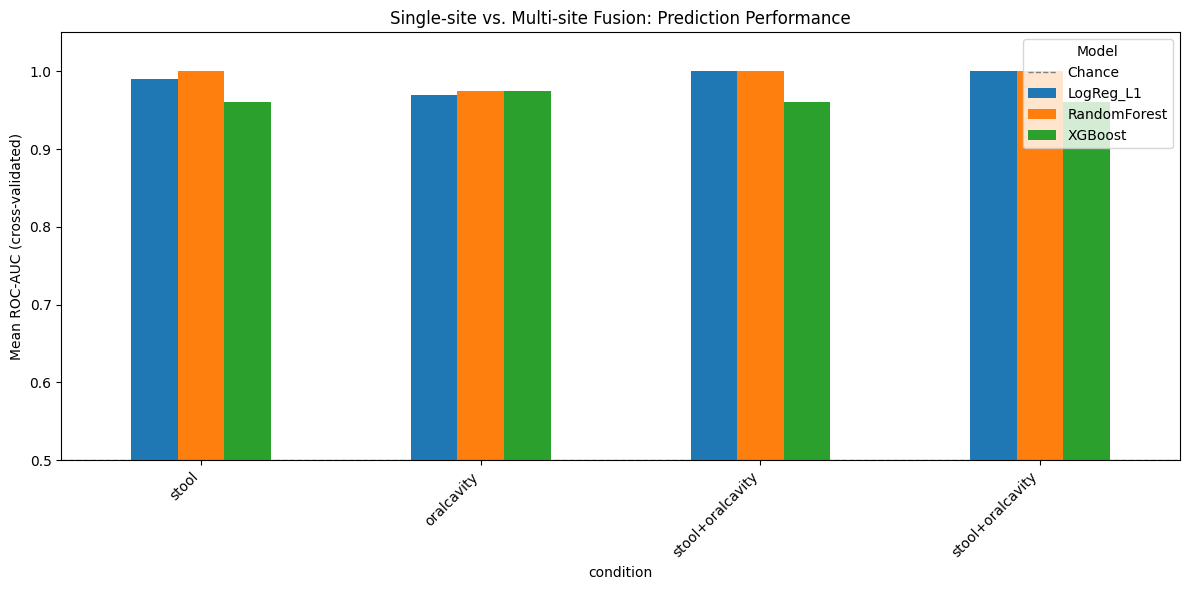

In [ ]:
plt.figure(figsize=(12, 6))
pivot = results_df.pivot(index="condition", columns="model", values="mean_auc")
order = SITES_TO_USE + ["+".join(c) for c in combinations(SITES_TO_USE, 2)] + ["+".join(SITES_TO_USE)]
pivot = pivot.reindex(order)
pivot.plot(kind="bar", figsize=(12,6))
plt.ylabel("Mean ROC-AUC (cross-validated)")
plt.title("Single-site vs. Multi-site Fusion: Prediction Performance")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.5, 1.05)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("/content/results/performance_comparison.png", dpi=150)
plt.show()

In [ ]:
!pip install xgboost shap -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import shap
import warnings
warnings.filterwarnings("ignore")

 Interpretability: SHAP analysis on the best-performing condition

SHAP matrix shape: (44, 291) | X_best shape: (44, 291)


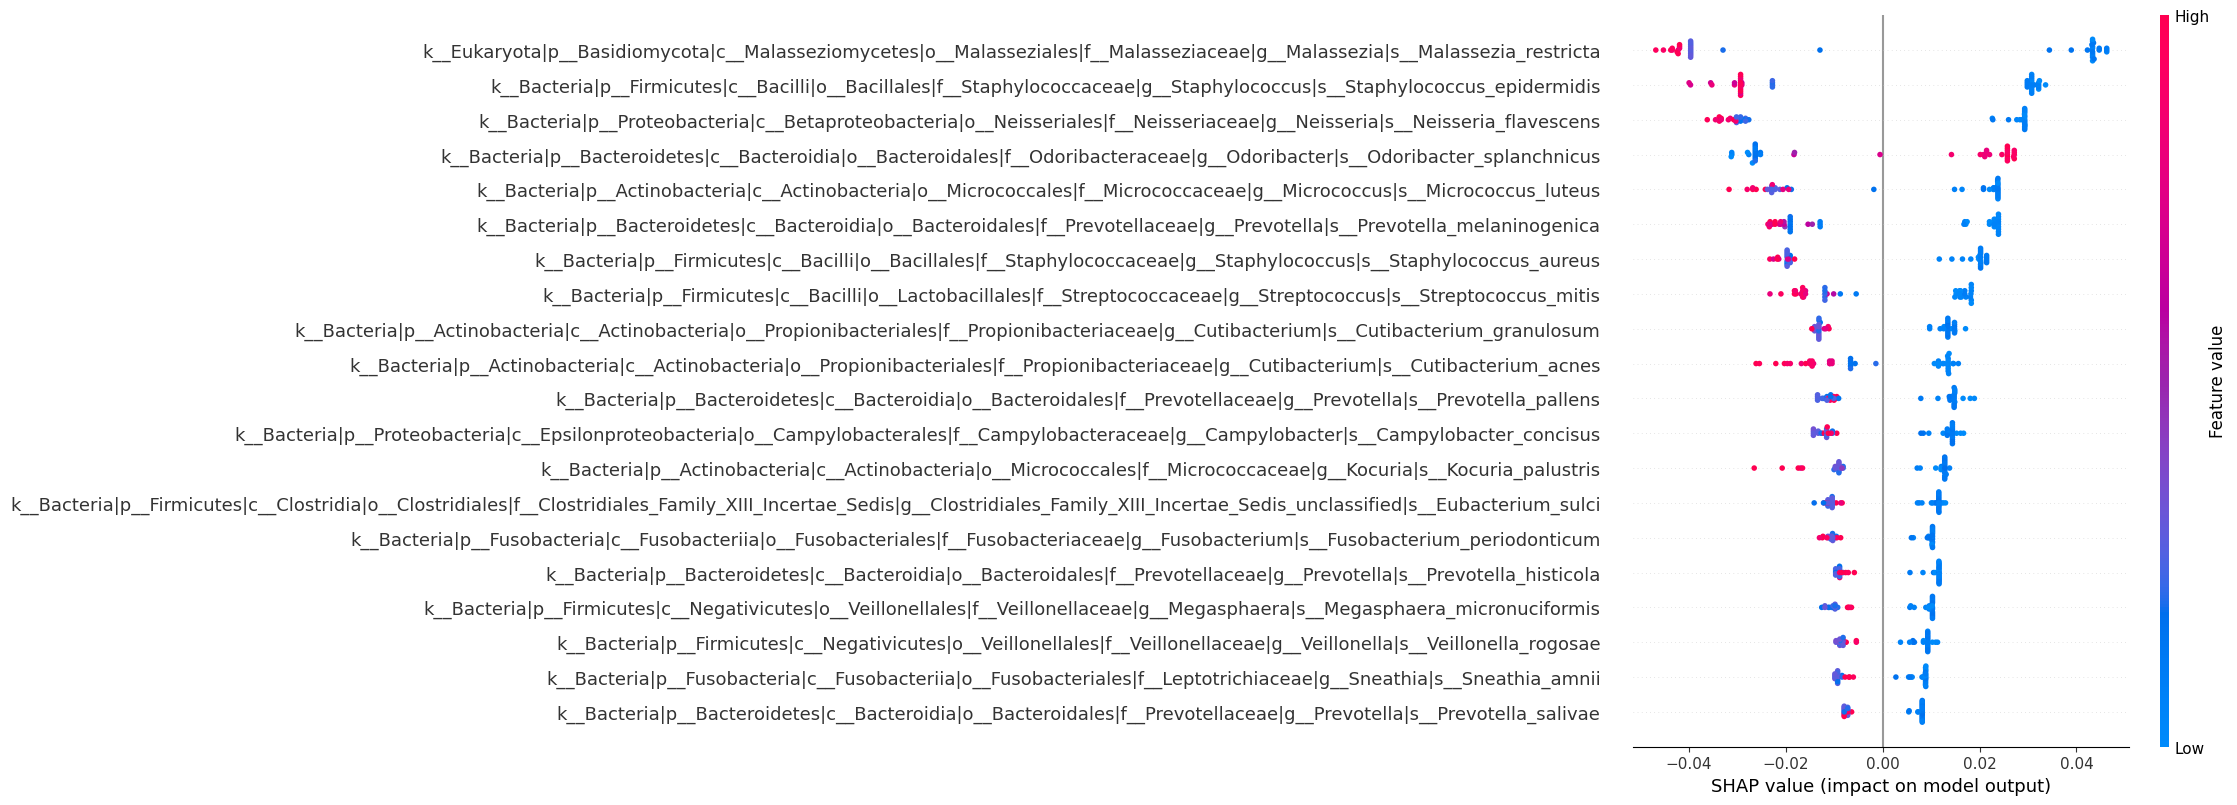

In [ ]:
best_row = results_df.loc[results_df["mean_auc"].idxmax()]
best_condition = best_row["condition"]
X_best = conditions[best_condition].fillna(0)

final_model = RandomForestClassifier(n_estimators=300, random_state=42)
final_model.fit(X_best, y_binary)
explainer = shap.TreeExplainer(final_model)

raw_shap = explainer.shap_values(X_best)

# Handle the plain 3D numpy array case: (samples, features, classes)
if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    shap_matrix = raw_shap[:, :, 1]   # class index 1 = "adult"
elif isinstance(raw_shap, list):
    shap_matrix = np.array(raw_shap[1])
elif hasattr(raw_shap, "values"):
    vals = raw_shap.values
    shap_matrix = vals[:, :, 1] if vals.ndim == 3 else vals
else:
    shap_matrix = np.array(raw_shap)

print("SHAP matrix shape:", shap_matrix.shape, "| X_best shape:", X_best.shape)
assert shap_matrix.shape == X_best.shape, "Still mismatched — paste this to Claude"

plt.figure()
shap.summary_plot(shap_matrix, X_best, max_display=20, show=False)
plt.tight_layout()
plt.savefig("/content/results/shap_summary_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
if "+" in best_condition:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feature_names = X_best.columns
    site_importance = {}
    for site in SITES_TO_USE:
        prefix = f"{site}__"
        idx = [i for i, f in enumerate(feature_names) if f.startswith(prefix)]
        site_importance[site] = mean_abs_shap[idx].sum() if idx else 0

    site_imp_df = pd.Series(site_importance).sort_values(ascending=False)
    print(site_imp_df)

    plt.figure(figsize=(6,4))
    site_imp_df.plot(kind="bar", color="steelblue")
    plt.ylabel("Total mean |SHAP value|")
    plt.title(f"Body-site contribution to prediction\n(condition: {best_condition})")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("/content/results/site_contribution.png", dpi=150)
    plt.show()
else:
    print(f"Best condition ({best_condition}) is single-site — no cross-site breakdown to show.")

Best condition (stool) is single-site — no cross-site breakdown to show.


In [ ]:
import shutil
shutil.make_archive("/content/microbiome_fusion_results", "zip", "/content/results")
print("Saved: /content/microbiome_fusion_results.zip")
print("Download this from the Colab file browser (folder icon on the left sidebar).")

Saved: /content/microbiome_fusion_results.zip
Download this from the Colab file browser (folder icon on the left sidebar).


SHAP matrix shape: (44, 444) | X_fused shape: (44, 444)

Total mean |SHAP| by site of origin:
oralcavity    0.292640
stool         0.210523
dtype: float64

Stool share: 41.8%
Oral share: 58.2%


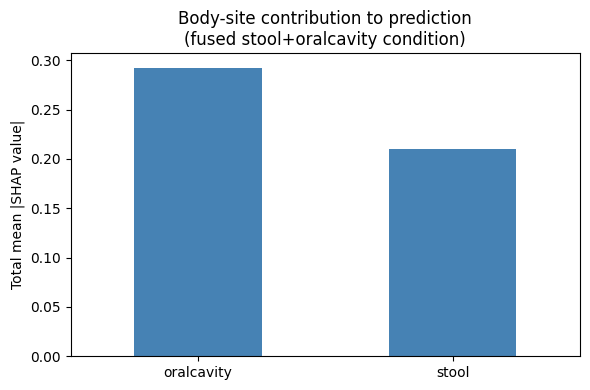

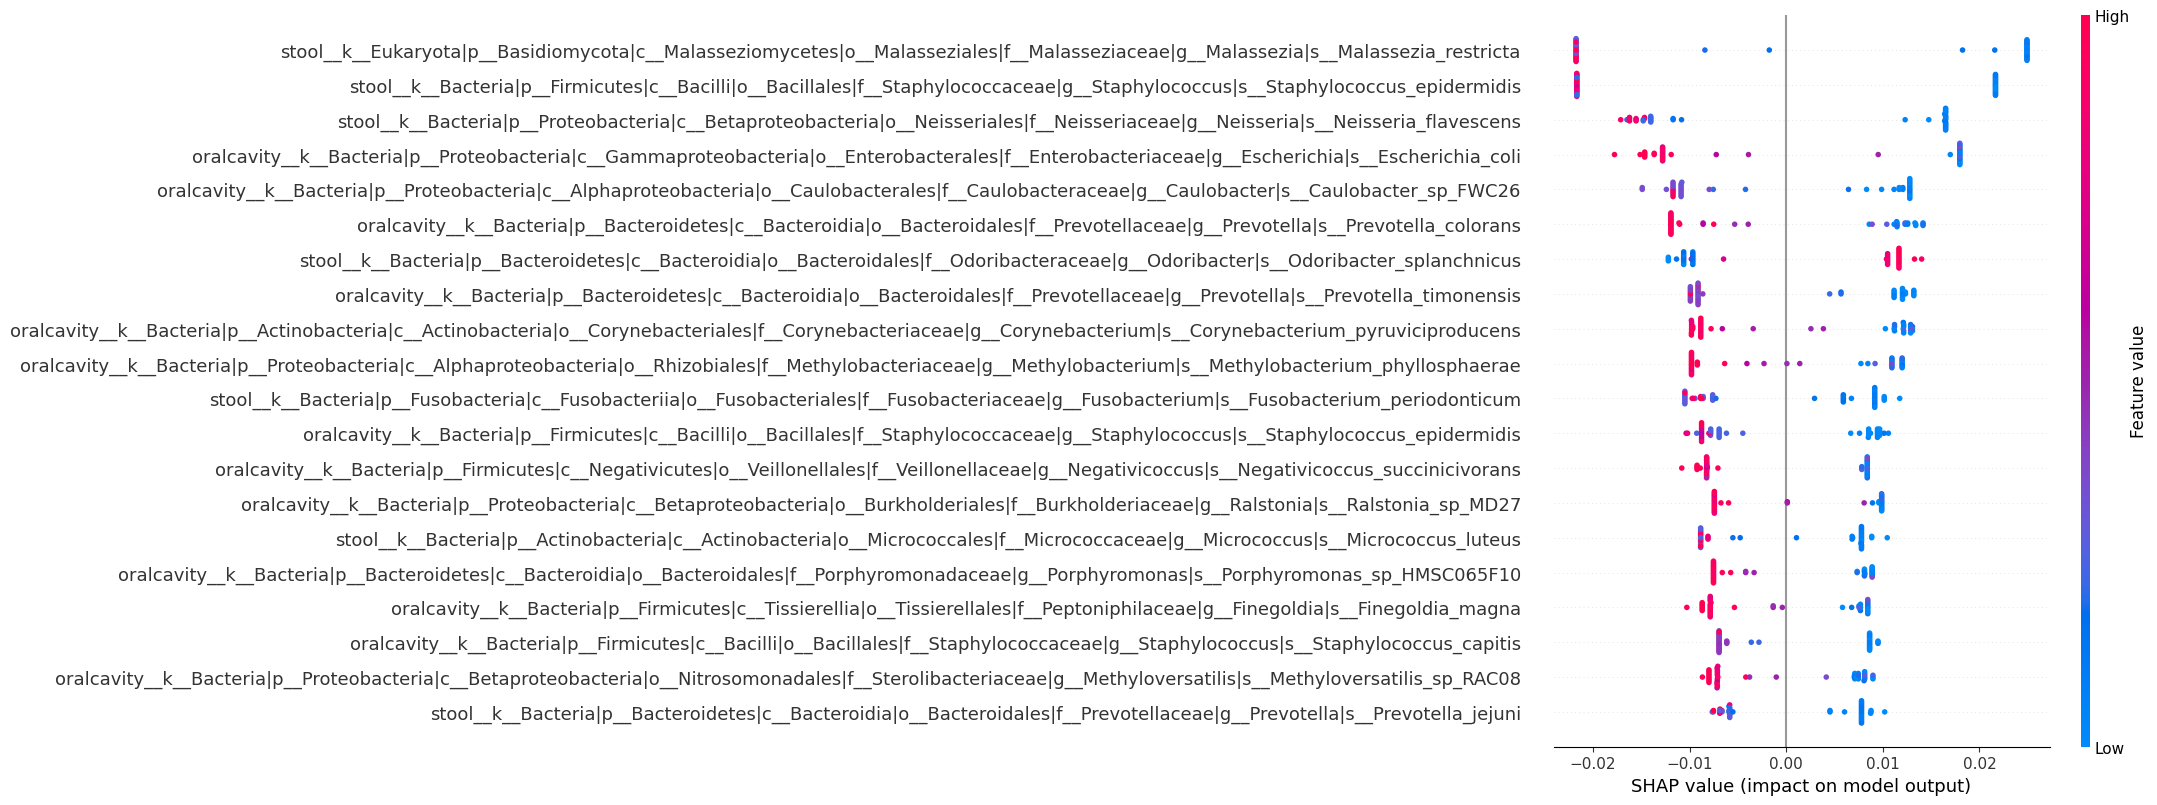

In [ ]:
# Supplementary analysis: force SHAP on the fused (stool+oralcavity) condition specifically,


forced_condition = "stool+oralcavity"
forced_model_name = "RandomForest"

X_fused = conditions[forced_condition].fillna(0)

final_model_fused = RandomForestClassifier(n_estimators=300, random_state=42)
final_model_fused.fit(X_fused, y_binary)
explainer_fused = shap.TreeExplainer(final_model_fused)

raw_shap_fused = explainer_fused.shap_values(X_fused)

if isinstance(raw_shap_fused, np.ndarray) and raw_shap_fused.ndim == 3:
    shap_matrix_fused = raw_shap_fused[:, :, 1]
elif isinstance(raw_shap_fused, list):
    shap_matrix_fused = np.array(raw_shap_fused[1])
elif hasattr(raw_shap_fused, "values"):
    vals = raw_shap_fused.values
    shap_matrix_fused = vals[:, :, 1] if vals.ndim == 3 else vals
else:
    shap_matrix_fused = np.array(raw_shap_fused)

print("SHAP matrix shape:", shap_matrix_fused.shape, "| X_fused shape:", X_fused.shape)
assert shap_matrix_fused.shape == X_fused.shape

# Per-site contribution breakdown
mean_abs_shap_fused = np.abs(shap_matrix_fused).mean(axis=0)
feature_names_fused = X_fused.columns
site_importance = {}
for site in ["stool", "oralcavity"]:
    prefix = f"{site}__"
    idx = [i for i, f in enumerate(feature_names_fused) if f.startswith(prefix)]
    site_importance[site] = mean_abs_shap_fused[idx].sum() if idx else 0

site_imp_df = pd.Series(site_importance).sort_values(ascending=False)
print("\nTotal mean |SHAP| by site of origin:")
print(site_imp_df)
print(f"\nStool share: {site_imp_df['stool'] / site_imp_df.sum() * 100:.1f}%")
print(f"Oral share: {site_imp_df['oralcavity'] / site_imp_df.sum() * 100:.1f}%")

plt.figure(figsize=(6,4))
site_imp_df.plot(kind="bar", color="steelblue")
plt.ylabel("Total mean |SHAP value|")
plt.title("Body-site contribution to prediction\n(fused stool+oralcavity condition)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/results/site_contribution_fused.png", dpi=150)
plt.show()


plt.figure()
shap.summary_plot(shap_matrix_fused, X_fused, max_display=20, show=False)
plt.tight_layout()
plt.savefig("/content/results/shap_summary_fused.png", dpi=150, bbox_inches="tight")
plt.show()

 SHAP dependence plots

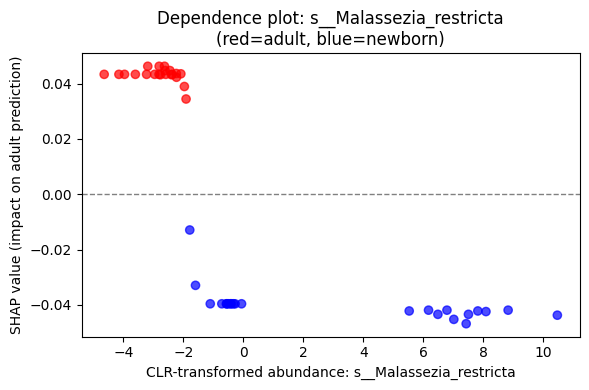

s__Malassezia_restricta: abundance-SHAP correlation = -0.740
  → Higher abundance pushes toward NEWBORN



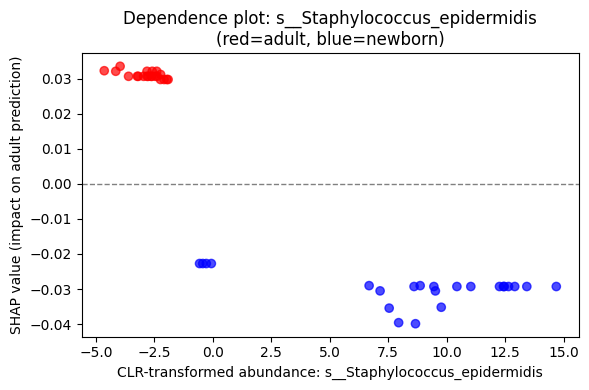

s__Staphylococcus_epidermidis: abundance-SHAP correlation = -0.884
  → Higher abundance pushes toward NEWBORN



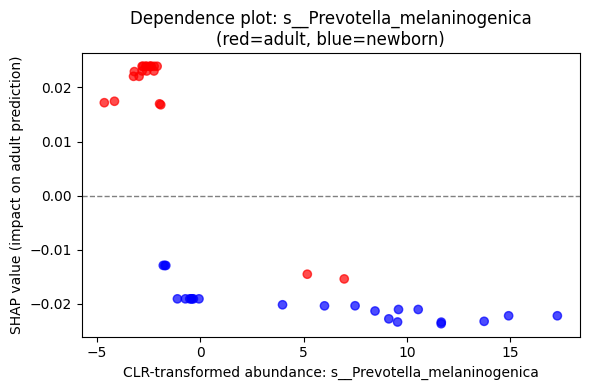

s__Prevotella_melaninogenica: abundance-SHAP correlation = -0.727
  → Higher abundance pushes toward NEWBORN

Stored 3 results in 'dependence_correlations'


In [ ]:
top_taxa = ["k__Eukaryota|p__Basidiomycota|c__Malasseziomycetes|o__Malasseziales|f__Malasseziaceae|g__Malassezia|s__Malassezia_restricta",
            "k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Staphylococcaceae|g__Staphylococcus|s__Staphylococcus_epidermidis",
            "k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__Prevotella|s__Prevotella_melaninogenica"]

dependence_correlations = []

for taxon in top_taxa:
    if taxon not in X_best.columns:
        print(f"Skipping {taxon} — not found in X_best columns, check exact name")
        continue
    idx = list(X_best.columns).index(taxon)
    abundance_vals = X_best[taxon].values
    shap_vals = shap_matrix[:, idx]

    plt.figure(figsize=(6,4))
    colors = ["red" if label == 1 else "blue" for label in y_binary]
    plt.scatter(abundance_vals, shap_vals, c=colors, alpha=0.7)
    plt.xlabel(f"CLR-transformed abundance: {taxon.split('|')[-1]}")
    plt.ylabel("SHAP value (impact on adult prediction)")
    plt.title(f"Dependence plot: {taxon.split('|')[-1]}\n(red=adult, blue=newborn)")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.savefig(f"/content/results/dependence_{taxon.split('|')[-1]}.png", dpi=150)
    plt.show()

    corr = np.corrcoef(abundance_vals, shap_vals)[0,1]
    direction = "Higher abundance pushes toward ADULT" if corr > 0 else "Higher abundance pushes toward NEWBORN"
    print(f"{taxon.split('|')[-1]}: abundance-SHAP correlation = {corr:.3f}")
    print(f"  → {direction}\n")


    dependence_correlations.append({
        "taxon": taxon.split('|')[-1],
        "full_taxon_name": taxon,
        "correlation": float(corr),
        "direction": direction
    })

print("Stored", len(dependence_correlations), "results in 'dependence_correlations'")

 Null baseline (label shuffling)



Null (shuffled-label) AUC: mean = 0.500, std = 0.156
Real AUC (stool, Random Forest) = 1.000
Gap confirms real signal, not leakage


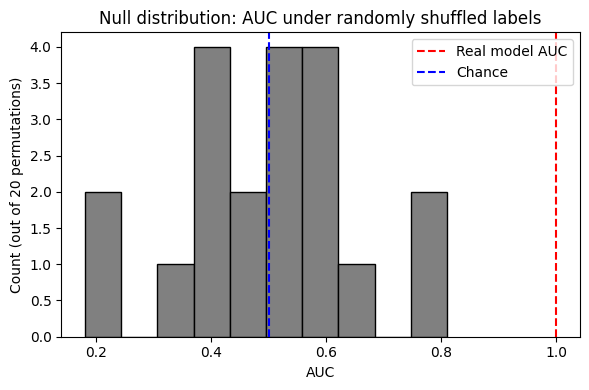

In [ ]:
from sklearn.utils import shuffle

n_permutations = 20
null_aucs = []

X_stool = conditions["stool"].fillna(0)

for i in range(n_permutations):
    y_shuffled = shuffle(y_binary.values, random_state=i)
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    scores = cross_val_score(model, X_stool, y_shuffled, cv=cv, scoring="roc_auc")
    null_aucs.append(scores.mean())

null_aucs = np.array(null_aucs)
print(f"Null (shuffled-label) AUC: mean = {null_aucs.mean():.3f}, std = {null_aucs.std():.3f}")
print(f"Real AUC (stool, Random Forest) = 1.000")
print("Gap confirms real signal, not leakage" if null_aucs.mean() < 0.65 else "WARNING: null AUC too high, investigate leakage")

plt.figure(figsize=(6,4))
plt.hist(null_aucs, bins=10, color="gray", edgecolor="black")
plt.axvline(1.0, color="red", linestyle="--", label="Real model AUC")
plt.axvline(0.5, color="blue", linestyle="--", label="Chance")
plt.xlabel("AUC")
plt.ylabel("Count (out of 20 permutations)")
plt.title("Null distribution: AUC under randomly shuffled labels")
plt.legend()
plt.tight_layout()
plt.savefig("/content/results/null_baseline.png", dpi=150)
plt.show()

 Bootstrap confidence intervals on AUC



In [ ]:
from sklearn.utils import resample

def bootstrap_auc_ci(X, y, model_fn, n_bootstrap=200, ci=95):
    aucs = []
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    for i in range(n_bootstrap):
        idx = resample(range(len(y)), replace=True, random_state=i, stratify=y)
        X_bs, y_bs = X.iloc[idx], y.iloc[idx]
        if len(set(y_bs)) < 2:
            continue
        model = model_fn()
        scores = cross_val_score(model, X_bs, y_bs, cv=3, scoring="roc_auc")
        aucs.append(scores.mean())
    aucs = np.array(aucs)
    lower = np.percentile(aucs, (100-ci)/2)
    upper = np.percentile(aucs, 100-(100-ci)/2)
    return aucs.mean(), lower, upper

mean_auc, ci_low, ci_high = bootstrap_auc_ci(
    conditions["stool"].fillna(0), y_binary,
    lambda: RandomForestClassifier(n_estimators=300, random_state=42)
)
print(f"Stool + Random Forest: AUC = {mean_auc:.3f}, 95% CI = [{ci_low:.3f}, {ci_high:.3f}]")

mean_auc_f, ci_low_f, ci_high_f = bootstrap_auc_ci(
    conditions["stool+oralcavity"].fillna(0), y_binary,
    lambda: RandomForestClassifier(n_estimators=300, random_state=42)
)
print(f"Fused + Random Forest: AUC = {mean_auc_f:.3f}, 95% CI = [{ci_low_f:.3f}, {ci_high_f:.3f}]")

Stool + Random Forest: AUC = 0.997, 95% CI = [0.976, 1.000]
Fused + Random Forest: AUC = 0.998, 95% CI = [0.982, 1.000]


 Preprocessing sensitivity check



In [ ]:
def preprocess_variant(raw_df, pseudocount, min_variance):
    filtered = raw_df.loc[:, raw_df.var(axis=0) > min_variance]
    df = filtered + pseudocount
    log_df = np.log(df)
    gm = log_df.mean(axis=1)
    return log_df.sub(gm, axis=0)

variants = [
    {"pseudocount": 1e-6, "min_variance": 1e-4, "label": "original"},
    {"pseudocount": 1e-5, "min_variance": 1e-4, "label": "10x pseudocount"},
    {"pseudocount": 1e-6, "min_variance": 1e-3, "label": "stricter variance filter"},
]

print("Sensitivity check: stool-only Random Forest AUC across preprocessing variants\n")
for v in variants:
    X_variant = preprocess_variant(site_tables[SITES_TO_USE[0]], v["pseudocount"], v["min_variance"]).loc[common_subjects].fillna(0)
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    scores = cross_val_score(model, X_variant, y_binary, cv=cv, scoring="roc_auc")
    print(f"{v['label']:30s} | features={X_variant.shape[1]:4d} | AUC = {scores.mean():.3f} \u00b1 {scores.std():.3f}")

Sensitivity check: stool-only Random Forest AUC across preprocessing variants

original                       | features= 291 | AUC = 1.000 ± 0.000
10x pseudocount                | features= 291 | AUC = 1.000 ± 0.000
stricter variance filter       | features= 227 | AUC = 1.000 ± 0.000
